<h1><center> Laboratorio di WebScraping </h1>
<h1><center> Anno Accademico 2023-2024 </h1>
<h1><center>  Docente: Laura Ricci </h1>
<h1><center>  Lezione 20 </h1>
<h1><center>  Tecniche di Scraping avanzato </h1> 
<h1><center>  Serie temporali </h1> 
<h1><center> 24 Aprile 2024 </h1>

## Cosa è un User Agent?

* uno **User Agent (UA)** è una stringa inviata dal web browser ad un server
* inserita nell'header **HTTP** ed identifica 
    * tipo del device
    * tipo del browser
    * la versione
    * il sistema operativo
* utilizzata del web server per identificare il richiedente e inviare il contenuto in modo che sia compatibile con il browser



## La libreria Fake_UserAgent

* sostituisce l'user agent di default utilizzato nella libreria request
* scopo: far apparire lo scraper come un browser 
* genera un **user-agent casuale** per ogni **richiesta HTTP**
* consente di emulare il comportamento di un browser e (in parte) di evitare di essere bloccati dai server
* non presente di default in Python, per installarla è necessario eseguire il comando **pip install** 

## La libreria Fake_UserAgent

In [1]:
import requests
from fake_useragent import UserAgent
 
ua = UserAgent() 
# Ottenere un User Agent random
random_ua = ua.random
 
url = 'http://google.com'
 # Passare lo user-agent random come header della richiesta
request_headers = {'user-agent': random_ua }
response = requests.get(url, headers= request_headers)
if response.status_code == 200:
    print(response.request.headers['User-Agent'])
else:
    print(response.status_code)
    

Mozilla/5.0 (Android 11; Mobile; rv:123.0) Gecko/123.0 Firefox/123.0


## La libreria Fake_UserAgent

* sotto si mostrano i risultati ottenuti da esecuzioni multiple della richiesta HTTP

* Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/17.0 DuckDuckGo/7 Safari/605.1.15
* Mozilla/5.0 (iPhone; CPU iPhone OS 17_0 like Mac OS X) AppleWebKit/605.1.15 (KHTML, like Gecko) EdgiOS/119.0.2151.105 Version/17.0 Mobile/15E148 Safari/604.1
* Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:123.0) Gecko/20100101 Firefox/123.0 OpenWave/94.4.4504.39
* Mozilla/5.0 (Linux; Android 10; K) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Mobile Safari/537.36
* Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:123.0) Gecko/20100101 Firefox/123.0
*....

## Capire la struttura di uno User Agent

* diversi campi di non sempre facile lettuta
* per decodificare uno User Agent, visitare il sito **UserAgentString.com**
* visualizza automaticamente lo **User Agent** per il browser da cui è stata mandata la richiesta
* possibile ottenere informazione per qualsiasi **User Agent** copiando la stringa nella forma e cliccando **Analyse**
* sotto l'analisi di uno degli User Agent precedenti

<center>
<img src="Figures/UserAgent.jpg" style="width:800px;height:800px;"/>

## Il problema del sovraccarico delle richieste ad un sito

* durante lo scraping  è importante considerare che molti servizi web, anche se ammettono lo scraping, implementano  misure
  di sicurezza per evitare il sovraccarico del server. 
* obiettivo delle misure: evitare attacchi di  **Denial of Service**
* accade spesso che se vengono inviate troppe richieste dallo stesso indirizzo **IP**, appaia un messaggio di errore come **Too many requests**
* altri siti utilizzano **CAPTCHA** per identificare possibili bots
* contromisure possibili
    * uso di **proxy** per evitare il blocco delle richieste provevnienti dallo stesso indirizzo **IP**
    * uso di tecniche di **intelligenza artificiale** per superare i **CAPTCHA**
* in questo corso, ci occuperemo solo della tecnica basata su **proxy**



## Come utilizzare i free proxy

* un proxy agisce come un intermediario tra lo script di scraping e il sito web di destinazione.
* sostituzione dell'indirizzo del proxy rispetto a quello originale
* l'utilizzo di **proxy** consente di aggirare il blocco degli **indirizzi IP**
* in realtà questo è solo parzialmente vero perchè anche i proxy possono avere il proprio indirizzo IP bloccato
    * è più difficile che questo accada per tutti i proxy rispetto che all'utilizzo di un singolo indirizzo IP per effettuare tutte le richieste
* utilizzando una lista di proxy, è possibile alternare l'indirizzo IP delle richieste 


## SSLProxies.ORG: un servizio di free proxies

<center>
<img src="Figures/FreeProxies.jpg" style="width:1000px;height:700px;"/>

## SSLProxies.ORG: scraping degli indirizzi dei free proxies

<center>
<img src="Figures/ProxiesList.jpg" style="width:1600px;height:800px;"/>

## Utilizzare SSLProxies.ORG

In [2]:
from urllib.request import Request, urlopen
from bs4 import BeautifulSoup
import random

proxies = [] # Lista che conterrà i proxy come dizionari con chiavi ip e porta
# Funzione per la estrazione dei proxy da sslproxies.org
def generate_proxies():
    proxies.clear() # Svuoto la lista dei proxy (nel caso la funzione venga chiamata più volte non si vogliono avere duplicati)
    proxies_req = Request('https://www.sslproxies.org/')
    proxies_req.add_header('User-Agent', ua.random)
    proxies_doc = urlopen(proxies_req).read().decode('utf8')
    soup = BeautifulSoup(proxies_doc, 'html.parser')
    proxies_table = soup.find('table', class_='table table-striped table-bordered')
    # Salvo i proxy nella lista proxies
    for row in proxies_table.tbody.find_all('tr'):
        td = row.find_all('td')
        proxies.append({
        'ip':   td[0].string,
        'port': td[1].string})
 


## Utilizzare SSLProxies.ORG

In [3]:
# Proxy ottenuti da sslproxies.org
generate_proxies()
print(f"Numero di proxy ottenuti da sslproxies.org: {len(proxies)}")
print(proxies)


Numero di proxy ottenuti da sslproxies.org: 100
[{'ip': '152.32.243.60', 'port': '8081'}, {'ip': '4.155.2.13', 'port': '9480'}, {'ip': '216.176.106.50', 'port': '8080'}, {'ip': '5.32.88.130', 'port': '8080'}, {'ip': '114.129.2.82', 'port': '8081'}, {'ip': '18.138.210.30', 'port': '8000'}, {'ip': '3.1.247.69', 'port': '8000'}, {'ip': '35.185.196.38', 'port': '3128'}, {'ip': '160.72.98.165', 'port': '3128'}, {'ip': '178.128.113.118', 'port': '23128'}, {'ip': '185.217.136.67', 'port': '1337'}, {'ip': '117.250.3.58', 'port': '8080'}, {'ip': '34.135.203.172', 'port': '3128'}, {'ip': '35.183.25.163', 'port': '8052'}, {'ip': '148.72.140.24', 'port': '30127'}, {'ip': '8.219.97.248', 'port': '80'}, {'ip': '67.43.228.253', 'port': '11063'}, {'ip': '34.126.125.90', 'port': '8080'}, {'ip': '140.238.247.9', 'port': '8100'}, {'ip': '181.129.138.114', 'port': '30838'}, {'ip': '72.10.160.174', 'port': '31537'}, {'ip': '67.43.227.228', 'port': '12643'}, {'ip': '69.197.135.43', 'port': '18080'}, {'ip': 

## Utilizzare SSLProxies.ORG e FakeUserAgent per lo scraping di WalletExplorer

In [4]:
import time
def get_service_name_walletexplorer(address, proxies):
    url = f"https://www.walletexplorer.com/address/{address}"
    original_proxy_count = len(proxies)
    while True:
        if len(proxies) == 0:
            print(f"Numero massimo di proxy bloccati raggiunto. Terminazione. ({original_proxy_count})")
            raise StopIteration
        proxy = random.choice(proxies)
        print("usedproxie",proxy)
        user_agent = ua.random
        try:
            headers = {'User-Agent': user_agent}
            response = requests.get(url, headers=headers, proxies=proxy)
            print(response)
            soup = BeautifulSoup(response.text, 'html.parser')
            if response.text.startswith("Too"):
                 proxies.remove(proxy)
                 print(f"WalletExplorer ha bloccato l'IP del proxy. Cambio proxy... (numero di proxy rimanenti alla sospensione dell'esecuzione: {len(proxies)})")
                 time.sleep(5)  # Attendi 5 secondi prima di provare un nuovo proxy
                 continue
            wallet_note = soup.find('div', class_='walletnote')
            if wallet_note:
                service_name = wallet_note.find('a').text
                return service_name
            return None        
        except:
            proxies.remove(proxy)
            print(f"Errore durante la richiesta. Cambio proxy... (numero di proxy rimanenti alla sospensione dell'esecuzione: {len(proxies)})")
            time.sleep(5)  # Attendi 5 secondi prima di provare un nuovo proxy
            continue
            

## Utilizzare SSLProxies.ORG e FakeUserAgent per lo scraping di WalletExplorer

In [5]:
get_service_name_walletexplorer('3P14159f73E4gFr7JterCCQh9QjiTjiZrG', proxies)


usedproxie {'ip': '67.43.227.230', 'port': '32929'}
<Response [200]>


'Eligius.st'

## Dates, Time e Time Series

* perchè date, timestamp e time series sono così importanti in Pandas, tanto che è stato sviluppato un intero package per gestirli?
    * utili per analizzare **dati finanziari**
* i tipi offerti da **Pandas** per supportare le time series sono
    * **Timestamp** descrive un istante temporale (ad esempio, **July 4th, 2015 at 7:00am**)
        * indice associato **DatatimeIndex**
    * **Period** periodo di tempo (ad esempio anno, mese,,...)
        * indice associato **PeriodIndex**
    * **Timedelta**  indicano durate temporali (ad esempio, una durata di **22.56 secondi**)
        * indice associato **TimedeltaIndex**
                                                                    

## Dates e Time in Python

* anche in Python esistono costrutti per la gestione del tempo
* l'oggetto **datetime.datetime**, che fa parte della **standard library** di Python, rappresenta un **time stamp**.
* il costruttore accetta 
    * anno
    * mese (inizia da 1)
    * giorno
    * opzionale: ora, minuti, secondi, microsecondi
* ogni argomento deve essere intero
* non molto efficinete per array di grosse dimensioni di date e timestamp 


In [6]:
from datetime import datetime
# Rappresentare la seguente data:  November 18th, 1991, at 2:01 PM.
bday = datetime(1991, 11, 18, 14, 1)
print(bday)
# Trovare il  umero di giorni tra 11/18/1991 and 24/4/2024.
dt = datetime(2024, 4, 24) - bday
dt.days


1991-11-18 14:01:00


11845

## Python: la classe datetime.datetime

In [ ]:
 print(datetime.strptime("1991-11-18 / 14:01", "%Y-%m-%d / %H:%M"),
       datetime.strptime("1/22/1996", "%m/%d/%Y"),
       datetime.strptime("19-8, 1998", "%d-%m, %Y"), sep='\n')


* l'oggetto **datetime** ha un metodo parser, **strptime** che converte una stringa in un oggetto **datetime**
* il parser è molto flessibile, e può parsare date in diversi formati
* ad esempio se la data è nella foma **"Month/Day//Year::Hour"**, specificando il formato **"=%m/%d//%Y::%H"** si ottiene il parsing corretto della data


## Numpy: il tipo datetime64

* anche la libreria **numpy** definisce funzioni per la manipolazione di dati temporali

In [7]:
import numpy as np
date = np.array('2015-07-04', dtype=np.datetime64)
date


array('2015-07-04', dtype='datetime64[D]')

In [8]:
date + np.arange(12)


array(['2015-07-04', '2015-07-05', '2015-07-06', '2015-07-07',
       '2015-07-08', '2015-07-09', '2015-07-10', '2015-07-11',
       '2015-07-12', '2015-07-13', '2015-07-14', '2015-07-15'],
      dtype='datetime64[D]')

* molto più efficiente del tipo **datetime** di **Python**
* limitato ad una precisione a **64 bit**
* trade off tra **risoluzione temporale** e **massimo intervallo di tempo rappresentabile**


## PANDAS: la classe Timestamp

* la classe **Timestamp** combina
    * la facilità di utilizzo della classe **datetime** di **Python**
    * efficienza di **numpy.datetime64**
* come una **Series** è una estensione delle **lista Python**, l'oggetto **Timestamp** lo è dell'oggetto **datetime** 


In [9]:
import pandas as pd
import numpy as np
date = pd.to_datetime("4th of July, 2015")
date


Timestamp('2015-07-04 00:00:00')

In [10]:
date.strftime('%A')


'Saturday'

In [11]:
date + pd.to_timedelta(np.arange(12), 'D')


DatetimeIndex(['2015-07-04', '2015-07-05', '2015-07-06', '2015-07-07',
               '2015-07-08', '2015-07-09', '2015-07-10', '2015-07-11',
               '2015-07-12', '2015-07-13', '2015-07-14', '2015-07-15'],
              dtype='datetime64[ns]', freq=None)

## Indexing by time

* l'utilità vera delle librerie precedenti è poter **indicizzare dati in base ai timestamp**
* **DatetimeIndex**
    * un **indice Pandas** composto da**Timestamp** 
* **Time series**
   * una serie di oggetti con un indice di tipo **DateTimeIndex** 
* **DatetimeIndex** può essere costruito
    * mediante il costruttore
    * con la funzione **pd.to_datetime()** che parsa  una collezione di **date**  in un **DatetimeIndex**
    * il formato delle date è inferito, quando possibile, ma può essere specificato esplicitamente con una sintassi simile a quella di 
  **datetime.strptime()**
  

## Indexing by time

In [12]:
index = pd.DatetimeIndex(['2014-07-04', '2014-08-04',
                          '2015-07-04', '2015-08-04'])
data = pd.Series([0, 1, 2, 3], index=index)
print(type(data))
data


<class 'pandas.core.series.Series'>


2014-07-04    0
2014-08-04    1
2015-07-04    2
2015-08-04    3
dtype: int64

In [13]:
data['2015']


2015-07-04    2
2015-08-04    3
dtype: int64

In [14]:
data['2014-07-04':'2015-07-04']


2014-07-04    0
2014-08-04    1
2015-07-04    2
dtype: int64

## Indici-time-based per Series

In [15]:
index = pd.DatetimeIndex(['2014-07-04', '2014-08-04',
                          '2015-07-04', '2015-08-04'])
data = pd.Series([0, 1, 2, 3], index=index)
data


2014-07-04    0
2014-08-04    1
2015-07-04    2
2015-08-04    3
dtype: int64

## Generazione di indici-time-based

In [16]:
 pd.date_range(start='1/1/2016', end='1/1/2017', freq="2BMS" )


DatetimeIndex(['2016-01-01', '2016-03-01', '2016-05-02', '2016-07-01',
               '2016-09-01', '2016-11-01'],
              dtype='datetime64[ns]', freq='2BMS')

In [17]:
pd.date_range(start='9/28/2016 16:00',
end='9/28/2016 16:30', freq="10T")


C:\Users\ricci\AppData\Local\Temp\ipykernel_17400\253016094.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  pd.date_range(start='9/28/2016 16:00',


DatetimeIndex(['2016-09-28 16:00:00', '2016-09-28 16:10:00',
               '2016-09-28 16:20:00', '2016-09-28 16:30:00'],
              dtype='datetime64[ns]', freq='10min')

In [18]:
pd.date_range(start='9/28/2016 16:30', periods=5, freq="2h30min")


DatetimeIndex(['2016-09-28 16:30:00', '2016-09-28 19:00:00',
               '2016-09-28 21:30:00', '2016-09-29 00:00:00',
               '2016-09-29 02:30:00'],
              dtype='datetime64[ns]', freq='150min')

## Open Power System Data (OPSD) della Germany

* una time-series giornaliera con dati su vari tipi di energia prodotta in Germania e sui consumi
    * produzione e consumo di energia su base giornaliera valutate in **gigawatt-ore (GWh)**
    * focus sulle energie **rinnovabili**
* un file csv con le seguenti colonne
    * **Date**: la data (yyyy-mm-dd format)
    * **Consumption**: Electricity consumption in GWh
    * **Wind**:  Wind power production in GWh
    * **Solar**: Solar power production in GWh
    * **Wind+Solar**: Somma della produzione wind e solar in GWh
* analisi della produzione e del consumo di energia nel tempo
    * quando il consumo di energia è più alto o più basso?
    * la produzione di energia eolica e solare varia con le stagioni dell'anno?
    * quali sono i trend a lungo termine?
    * confronto tra la produzione di energia eolica e solare e consumo di energia elettrica ecome varia nel tempo?


## Open Power System Data (OPSD) della Germany

In [19]:
import pandas as pd
opsd_daily = pd.read_csv('DataSets/opsd_germany_daily.csv', parse_dates=['Date'])
opsd_daily.shape


(4383, 5)

In [20]:
opsd_daily.head(3)


,Date,Consumption,Wind,Solar,Wind+Solar
0,2006-01-01,1069.184,NaN,NaN,NaN
1,2006-01-02,1380.521,NaN,NaN,NaN
2,2006-01-03,1442.533,NaN,NaN,NaN


In [21]:
opsd_daily.tail(3)


,Date,Consumption,Wind,Solar,Wind+Solar
4380,2017-12-29,1295.08753,584.277,29.854,614.131
4381,2017-12-30,1215.44897,721.247,7.467,728.714
4382,2017-12-31,1107.11488,721.176,19.980,741.156


In [22]:
opsd_daily.dtypes


Date           datetime64[ns]
Consumption           float64
Wind                  float64
Solar                 float64
Wind+Solar            float64
dtype: object

## Costruire la time series

In [23]:
opsd_daily = opsd_daily.set_index('Date')
opsd_daily.head(3)


,Consumption,Wind,Solar,Wind+Solar
Date,,,,
2006-01-01,1069.184,NaN,NaN,NaN
2006-01-02,1380.521,NaN,NaN,NaN
2006-01-03,1442.533,NaN,NaN,NaN


In [24]:
opsd_daily.index


DatetimeIndex(['2006-01-01', '2006-01-02', '2006-01-03', '2006-01-04',
               '2006-01-05', '2006-01-06', '2006-01-07', '2006-01-08',
               '2006-01-09', '2006-01-10',
               ...
               '2017-12-22', '2017-12-23', '2017-12-24', '2017-12-25',
               '2017-12-26', '2017-12-27', '2017-12-28', '2017-12-29',
               '2017-12-30', '2017-12-31'],
              dtype='datetime64[ns]', name='Date', length=4383, freq=None)

## Utilizzare le componenti dell'oggetto Timestamp

In [25]:
# Add columns with year, month, and weekday name
opsd_daily['Year'] = opsd_daily.index.year
opsd_daily['Month'] = opsd_daily.index.month
opsd_daily['Weekday Name'] = opsd_daily.index.dayofweek
# Display a random sampling of 5 rows
opsd_daily.sample(5, random_state=0)


,Consumption,Wind,Solar,Wind+Solar,Year,Month,Weekday Name
Date,,,,,,,
2008-08-23,1152.011,NaN,NaN,NaN,2008,8,5
2013-08-08,1291.984,79.666,93.371,173.037,2013,8,3
2009-08-27,1281.057,NaN,NaN,NaN,2009,8,3
2015-10-02,1391.050,81.229,160.641,241.870,2015,10,4
2009-06-02,1201.522,NaN,NaN,NaN,2009,6,1


## Time-based indexing

* **usare date e tempo per accedere ai dati**, accedendo mediante **loc**

In [26]:
opsd_daily.loc['2017-08-10']


Consumption     1351.491
Wind             100.274
Solar             71.160
Wind+Solar       171.434
Year            2017.000
Month              8.000
Weekday Name       3.000
Name: 2017-08-10 00:00:00, dtype: float64

In [27]:
opsd_daily.loc['2014-01-20':'2014-01-22']


,Consumption,Wind,Solar,Wind+Solar,Year,Month,Weekday Name
Date,,,,,,,
2014-01-20,1590.687,78.647,6.371,85.018,2014,1,0
2014-01-21,1624.806,15.643,5.835,21.478,2014,1,1
2014-01-22,1625.155,60.259,11.992,72.251,2014,1,2


## Partial Timestamp indexing

In [28]:
opsd_daily.loc['2012-02']


,Consumption,Wind,Solar,Wind+Solar,Year,Month,Weekday Name
Date,,,,,,,
2012-02-01,1511.866,199.607,43.502,243.109,2012,2,2
2012-02-02,1563.407,73.469,44.675,118.144,2012,2,3
2012-02-03,1563.631,36.352,46.510,82.862,2012,2,4
2012-02-04,1372.614,20.551,45.225,65.776,2012,2,5
2012-02-05,1279.432,55.522,54.572,110.094,2012,2,6
2012-02-06,1574.766,34.896,55.389,90.285,2012,2,0
2012-02-07,1615.078,100.312,19.867,120.179,2012,2,1
2012-02-08,1613.774,93.763,36.930,130.693,2012,2,2
2012-02-09,1591.532,132.219,19.042,151.261,2012,2,3


## Time series: visualizzazione

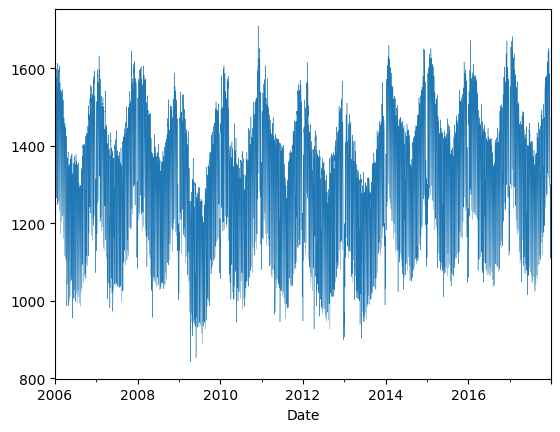

In [29]:
import matplotlib.pyplot as plt
opsd_daily['Consumption'].plot(linewidth=0.3);


* il metodo **plot()** ha scelto di inserire un tick ogni due anni e le label (gli anni) per l'asse delle x


## Time series: confronto tra produzione e consumi

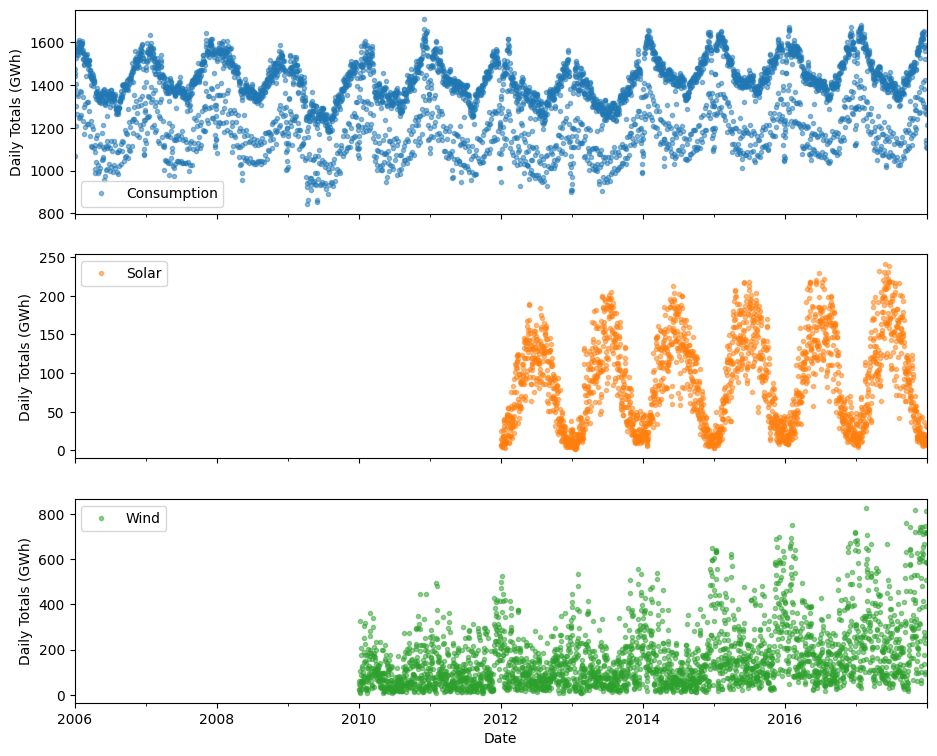

In [30]:
cols_plot = ['Consumption', 'Solar', 'Wind']
axes = opsd_daily[cols_plot].plot(marker='.', alpha=0.5, linestyle='None', figsize=(11, 9), subplots=True)
for ax in axes:
    ax.set_ylabel('Daily Totals (GWh)')
    

## Time series: Seasonality

* tutti i tre diagrammi mostrano una forte **periodicità**, riferita come **seasonality** nella analisi delle time series
    * un pattern che si ripete periodicamente a **intervalli regolari**
    * non sempre la caratteristica di  **seasonality** di una serie riguarda le stagioni metereologiche
    * ad esempio andamento vendite, maggiore a Novembre e a Dicembre
* differenti scale di **seasonality**
    * se si vuole individuare una eventuale week seasonality, occorre zoommare nel singolo anno
    

## Time series: Week Seasonality

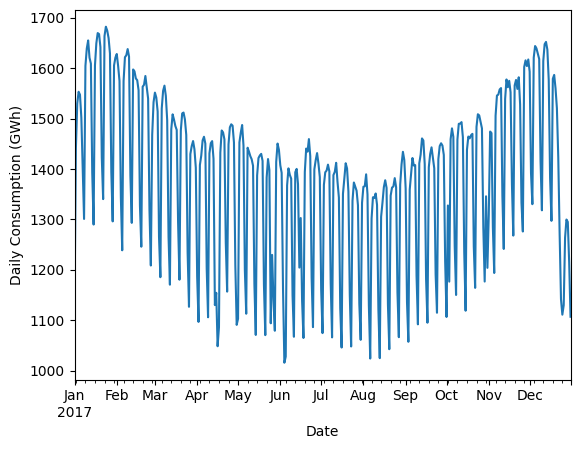

In [31]:
ax = opsd_daily.loc['2017', 'Consumption'].plot()
ax.set_ylabel('Daily Consumption (GWh)');


* il grafico presenta chairament la **week seasonality**
* si osserva anche la diminuzione di elettricità negli ultimi giorni di Dicembre e nei primi mesi di Gennaio, a causa delle vacanze


## TimeSeries: analizzare un periodo

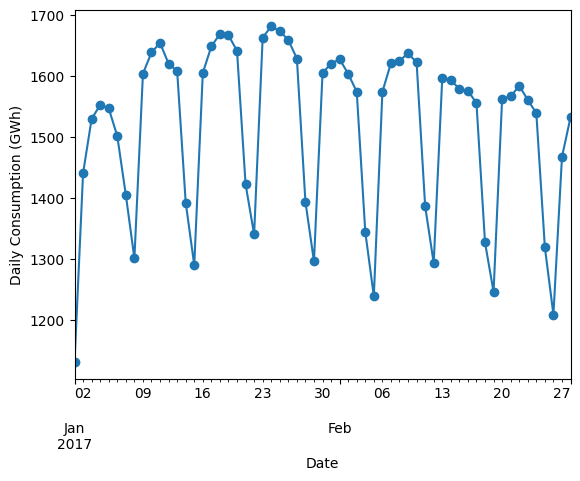

In [32]:
ax = opsd_daily.loc['2017-01':'2017-02', 'Consumption'].plot(marker='o', linestyle='-')
ax.set_ylabel('Daily Consumption (GWh)');


* maggiore consumo di energia durante i giorni feriali, e picco negativo nei giorni festivi


## Seasonality con i box plot

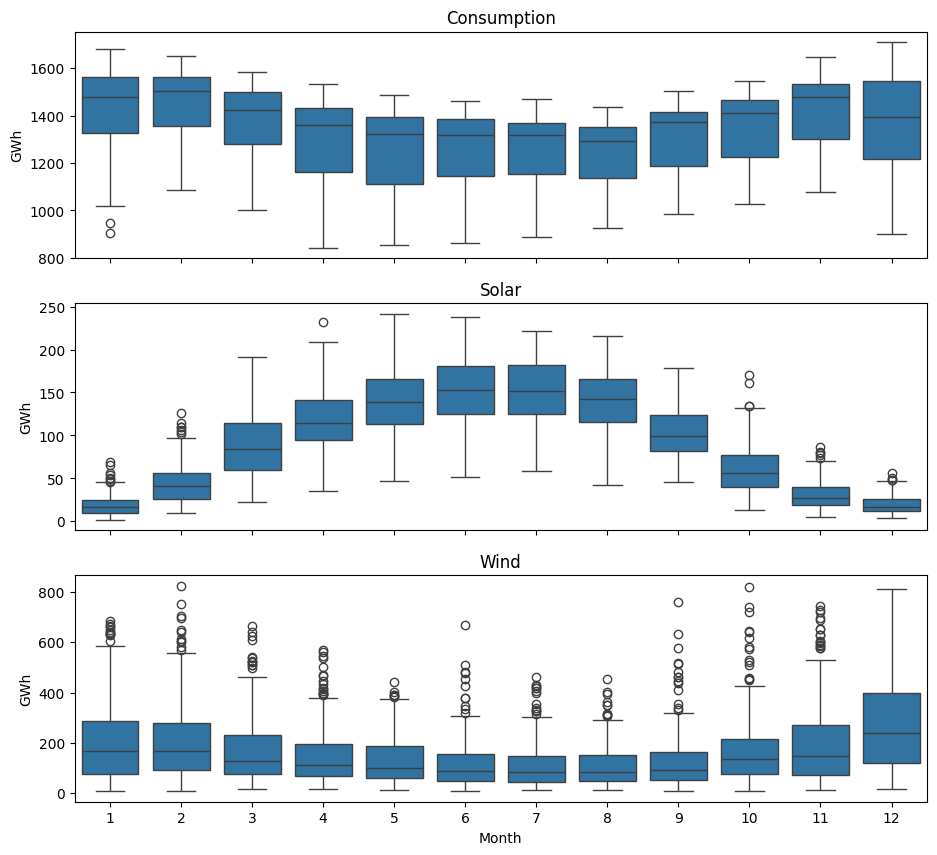

In [33]:
import seaborn as sns
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
for name, ax in zip(['Consumption', 'Solar', 'Wind'], axes):
    sns.boxplot(data=opsd_daily, y=name, x='Month', ax=ax)
    ax.set_ylabel('GWh')
    ax.set_title(name)
    

## Seasonality con i box plot

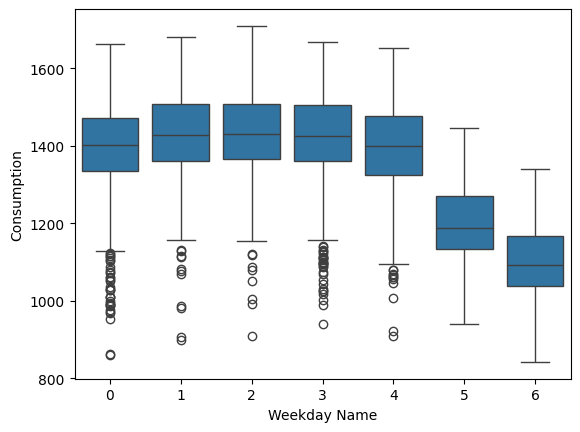

In [34]:
sns.boxplot(data=opsd_daily, x='Weekday Name', y='Consumption');


## Resampling

* modificare la serie modificando la **frequenza** di campionamento
    * **downsampling**: aggregazione
    * **upsampling**: interpolazione
* Pandas offre il metodo **resample**, che nel caso del downsampling
    * divide l'indice **DatetimeIndex** in bins
    * raggruppamento e aggregazione dei dati in ogni bin
    * possibile applicare diverse funzioni di aggregazione
* restituisce un oggetto **Resampler**
* simile alla **GroupBy**
    

## Downsampling

In [35]:
# Specify the data columns we want to include (i.e. exclude Year, Month, Weekday Name)
data_columns = ['Consumption', 'Wind', 'Solar', 'Wind+Solar']
# Resample to weekly frequency, aggregating with mean
opsd_weekly_mean = opsd_daily[data_columns].resample('W').mean()
opsd_weekly_mean.head(3)


,Consumption,Wind,Solar,Wind+Solar
Date,,,,
2006-01-01,1069.184000,NaN,NaN,NaN
2006-01-08,1381.300143,NaN,NaN,NaN
2006-01-15,1486.730286,NaN,NaN,NaN


In [36]:
print(opsd_daily.shape[0])
print(opsd_weekly_mean.shape[0])


4383
627


* la serie temporale include ora **1/7 dei dati originari**

## Daily e Weekly time series

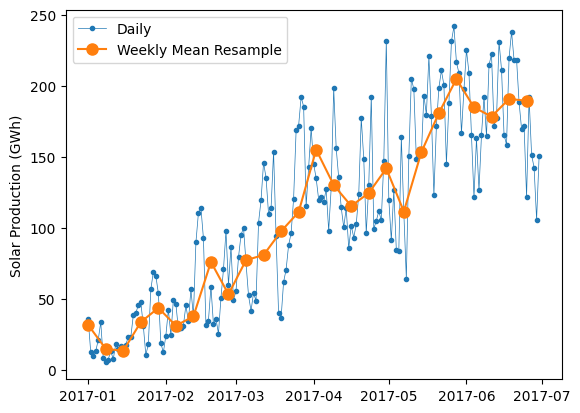

In [37]:
# Start and end of the date range to extract
start, end = '2017-01', '2017-06'
# Plot daily and weekly resampled time series together
fig, ax = plt.subplots()
ax.plot(opsd_daily.loc[start:end, 'Solar'],
marker='.', linestyle='-', linewidth=0.5, label='Daily')
ax.plot(opsd_weekly_mean.loc[start:end, 'Solar'],
marker='o', markersize=8, linestyle='-', label='Weekly Mean Resample')
ax.set_ylabel('Solar Production (GWh)')
ax.legend();


## Month Resampling

In [38]:
# Compute the monthly sums, setting the value to NaN for any month which has
# fewer than 28 days of data
opsd_monthly = opsd_daily[data_columns].resample('M').sum(min_count=28)
opsd_monthly.head(3)


C:\Users\ricci\AppData\Local\Temp\ipykernel_17400\2392188835.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  opsd_monthly = opsd_daily[data_columns].resample('M').sum(min_count=28)


,Consumption,Wind,Solar,Wind+Solar
Date,,,,
2006-01-31,45304.704,NaN,NaN,NaN
2006-02-28,41078.993,NaN,NaN,NaN
2006-03-31,43978.124,NaN,NaN,NaN


## Month Resample

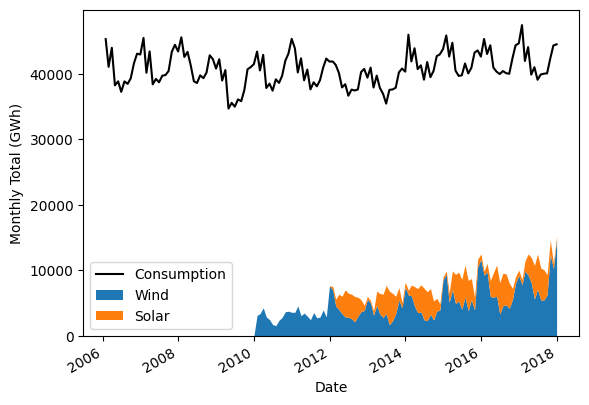

In [39]:
fig, ax = plt.subplots()
ax.plot(opsd_monthly['Consumption'], color='black', label='Consumption')
opsd_monthly[['Wind', 'Solar']].plot.area(ax=ax, linewidth=0)
ax.legend()
ax.set_ylabel('Monthly Total (GWh)');


## Rolling windows

* un intervallo di dimensione fissa (finestra) che si muove sequenzialmente su un Dataset più ampio dell'intervallo
* posso appalicare ad ogni intervallo una funzione di **aggregazione**
* a differenza del **downsampling**
    * le finestre temporali **si sovrappongono**
    * la frequenza di campionamento è la stessa di quella del dataset originario
    

<center>
<img src="Figures/RollingWindow.jpg" style="width:800px;height:500px;"/>

## Rolling windows

In [40]:
opsd_7d = opsd_daily[data_columns].rolling(7, center=True).mean()
opsd_7d.head(10)


,Consumption,Wind,Solar,Wind+Solar
Date,,,,
2006-01-01,NaN,NaN,NaN,NaN
2006-01-02,NaN,NaN,NaN,NaN
2006-01-03,NaN,NaN,NaN,NaN
2006-01-04,1361.471429,NaN,NaN,NaN
2006-01-05,1381.300143,NaN,NaN,NaN
2006-01-06,1402.557571,NaN,NaN,NaN
2006-01-07,1421.754429,NaN,NaN,NaN
2006-01-08,1438.891429,NaN,NaN,NaN
2006-01-09,1449.769857,NaN,NaN,NaN


## Rolling window

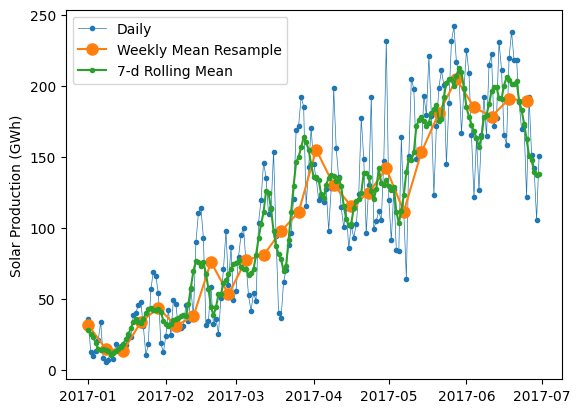

In [41]:
# Start and end of the date range to extract
start, end = '2017-01', '2017-06'
# Plot daily, weekly resampled, and 7-day rolling mean time series together
fig, ax = plt.subplots()
ax.plot(opsd_daily.loc[start:end, 'Solar'],
marker='.', linestyle='-', linewidth=0.5, label='Daily')
ax.plot(opsd_weekly_mean.loc[start:end, 'Solar'],
marker='o', markersize=8, linestyle='-', label='Weekly Mean Resample')
ax.plot(opsd_7d.loc[start:end, 'Solar'],
marker='.', linestyle='-', label='7-d Rolling Mean')
ax.set_ylabel('Solar Production (GWh)')
ax.legend();


## Rolling window

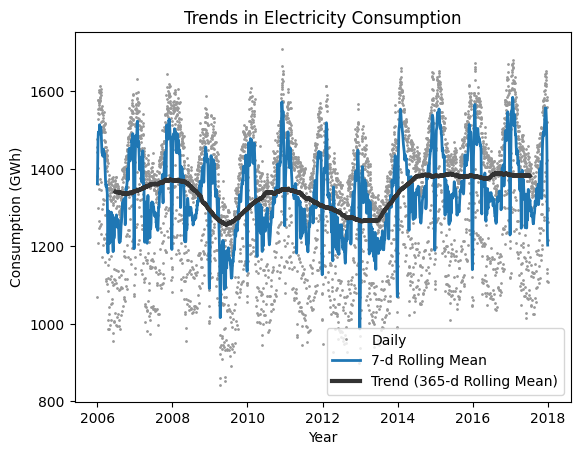

In [42]:
# The min_periods=360 argument accounts for a few isolated missing days in the
# wind and solar production time series
opsd_365d = opsd_daily[data_columns].rolling(window=365, center=True, min_periods=360).mean()
# Plot daily, 7-day rolling mean, and 365-day rolling mean time series
fig, ax = plt.subplots()
ax.plot(opsd_daily['Consumption'], marker='.', markersize=2, color='0.6',
linestyle='None', label='Daily')
ax.plot(opsd_7d['Consumption'], linewidth=2, label='7-d Rolling Mean')
ax.plot(opsd_365d['Consumption'], color='0.2', linewidth=3,
label='Trend (365-d Rolling Mean)')
ax.legend()
ax.set_xlabel('Year')
ax.set_ylabel('Consumption (GWh)')
ax.set_title('Trends in Electricity Consumption');



## Rolling windows

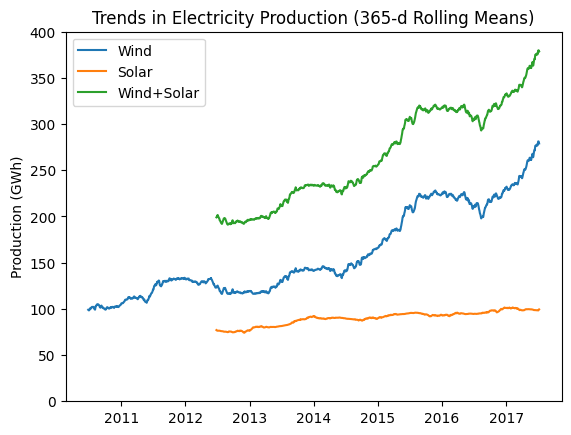

In [43]:
# Plot 365-day rolling mean time series of wind and solar power
fig, ax = plt.subplots()
for nm in ['Wind', 'Solar', 'Wind+Solar']:
    ax.plot(opsd_365d[nm], label=nm)
    # Set x-ticks to yearly interval, adjust y-axis limits, add legend and labels
    ax.set_ylim(0, 400)
    ax.legend()
    ax.set_ylabel('Production (GWh)')
    ax.set_title('Trends in Electricity Production (365-d Rolling Means)');
    